In [1]:
# importing necessary packages

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
# importing the dataset

df = pd.read_csv(r'C:\Users\liter\Downloads\telcocustomerdata.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
# quick check to see if the data has any issues ;

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\n/NaN:\n", df.replace(r'^\s*$', np.nan, regex=True).isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicated rows?:", df.duplicated().sum())
print("Duplicate customerID?:", df["customerID"].duplicated().sum())

Shape: (7043, 21)

Dtypes:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

/NaN:
 TotalCharges      11
gender             0
SeniorCitizen      0
Partner            0
customerID         0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
dtype: int64

Duplicated rows?: 0
Duplicate customerID?: 0


In [5]:
## START OF DATA CLEANING

In [6]:
# replacing missing values with NaN then converting them to numeric from object

df["TotalCharges"] = df["TotalCharges"].replace(r'^\s*$', np.nan, regex=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [7]:
# only 11 missing values, dropping the Nan values in TotalCharges; assuming customer profiles are not created and thus would be insignificant to the model.

df = df.dropna(subset=["TotalCharges"])

In [8]:
df.isna().sum() # checking to be sure 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# turning churn to be ready for model (numeric)

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

C:\Users\liter\AppData\Local\Temp\ipykernel_3380\2135163397.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)


In [10]:
# customer id is unnecessary for model training, dropping them

df = df.drop(columns=["customerID"])

In [11]:
# splitting numeric and categoric columns for modelling

target = "Churn"
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_cols = [c for c in df.columns if c not in numeric_cols + [target]]

print("\nNumeric cols:", numeric_cols)
print("Categorical cols count:", len(categorical_cols))
print("\nChurn:", df[target].value_counts(normalize=True))


Numeric cols: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical cols count: 15

Churn: Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


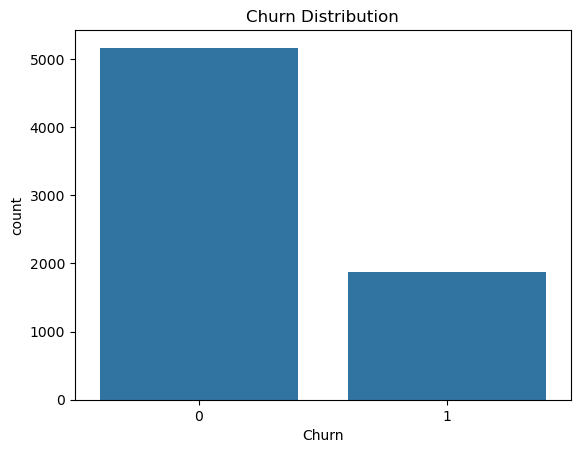

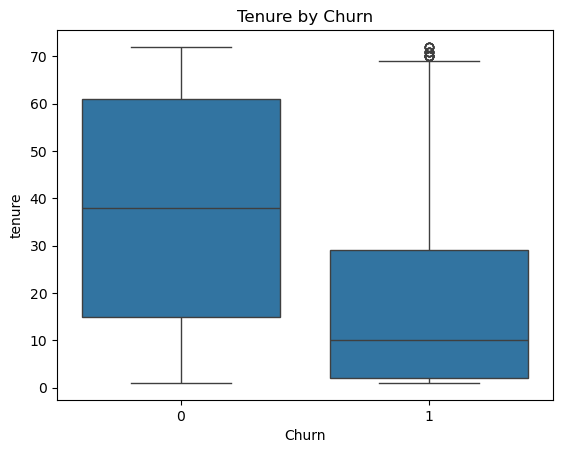

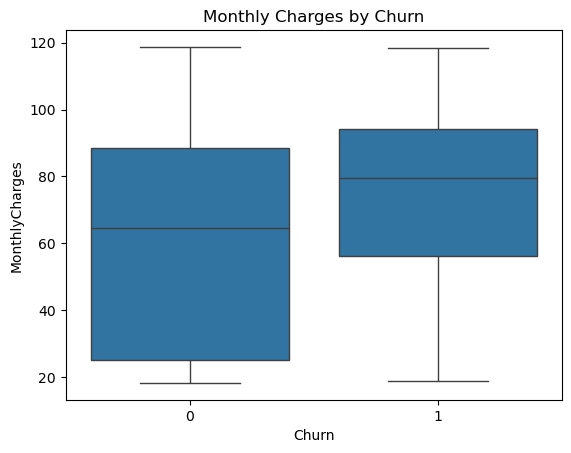

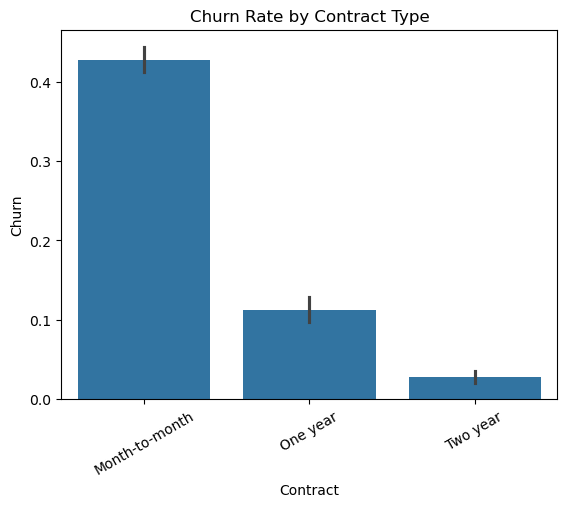

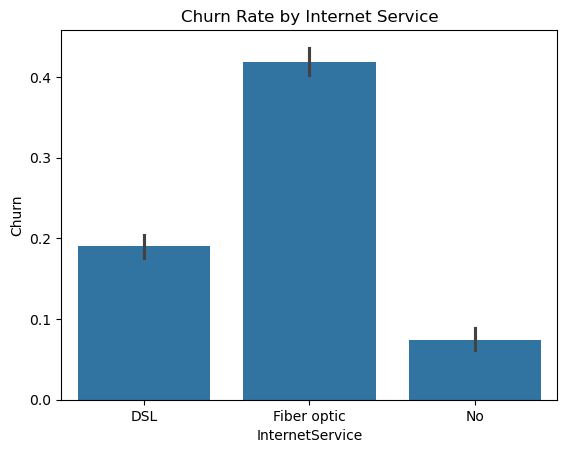

In [12]:
# Simple EDA

# Target distribution
df["Churn"].value_counts(normalize=True)

# Churn count plot
plt.figure()
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# Tenure vs Churn
plt.figure()
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn")
plt.show()

# MonthlyCharges vs Churn
plt.figure()
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

# Contract vs Churn
plt.figure()
sns.barplot(x="Contract", y="Churn", data=df)
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=30)
plt.show()

# InternetService vs Churn
plt.figure()
sns.barplot(x="InternetService", y="Churn", data=df)
plt.title("Churn Rate by Internet Service")
plt.show()

In [13]:
## END OF DATA CLEANING

In [14]:
## START OF MODELLING

In [15]:
# determinişng x and y

target_class = "Churn"

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_cols = [c for c in df.columns if c not in numeric_cols + [target_class]]

X = df.drop(columns=[target_class])
y = df[target_class]

In [16]:
# simple logistic regression test

# test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

# model pioeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

# training the model
clf.fit(X_train, y_train)

# predicting
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# result metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy : 0.8038379530916845
Precision: 0.6484848484848484
Recall   : 0.5721925133689839
F1       : 0.6079545454545454
ROC-AUC  : 0.8359290473207676

Confusion Matrix:
 [[917 116]
 [160 214]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [17]:
# Linear regression

target_reg = "Churn"

# determining x and y
Xr = df.drop(columns=[target_reg])
yr = df[target_reg]

# colons from xr
numeric_cols_reg = [c for c in Xr.columns if c in ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]]
categorical_cols_reg = [c for c in Xr.columns if c not in numeric_cols_reg]

# splity for 80/20
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42, stratify=yr
)

# preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_reg),
    ]
)

# linear reg pipeline
lin_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# train and predict
lin_reg.fit(Xr_train, yr_train)
yr_pred = lin_reg.predict(Xr_test)

# metrics
mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R^2 :", r2)

MAE : 0.3021129594984416
RMSE: 0.3801430179319377
R^2 : 0.2595251582160053


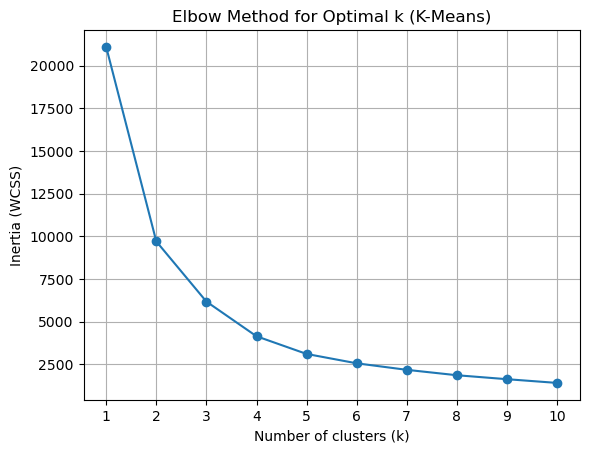

In [18]:
# elbow calculation

seg_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X = df[seg_cols].copy()

X_scaled = StandardScaler().fit_transform(X)

K_range = range(1, 11)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal k (K-Means)")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

In [20]:
# silhouette score for just in case

for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    print(k, "silhouette:", silhouette_score(X_scaled, labels))

3 silhouette: 0.45151338467627916
4 silhouette: 0.4720846608848589
5 silhouette: 0.4432685640601171



=== Cluster Summary (sorted by churn_rate) ===
            n  churn_rate  mean_tenure  mean_MonthlyCharges  \
Cluster                                                       
3        2273    0.483062    15.445227            80.791201   
0        1696    0.247642    10.277123            31.777771   
1        1904    0.153887    59.530987            93.306224   
2        1159    0.050043    53.585850            34.920147   

         mean_TotalCharges  median_tenure  median_MonthlyCharges  \
Cluster                                                            
3              1252.816564           14.0                  80.05   
0               303.821875            8.0                  24.85   
1              5548.653887           62.0                  95.05   
2              1836.581320           53.0                  25.35   

         median_TotalCharges  
Cluster                       
3                    1107.25  
0                     220.40  
1                    5449.65  
2        

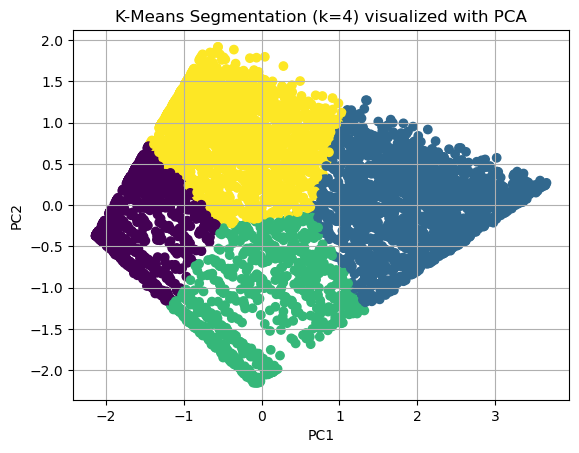

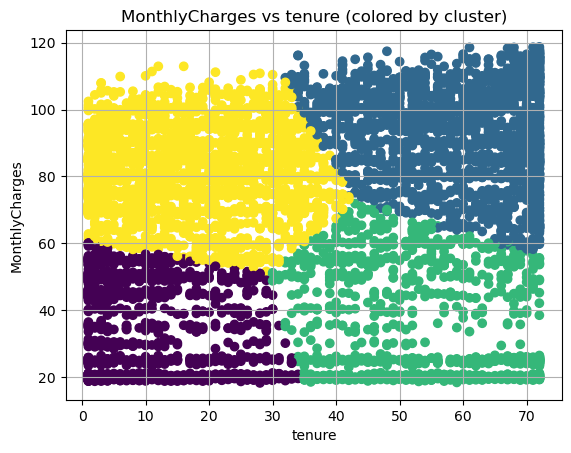

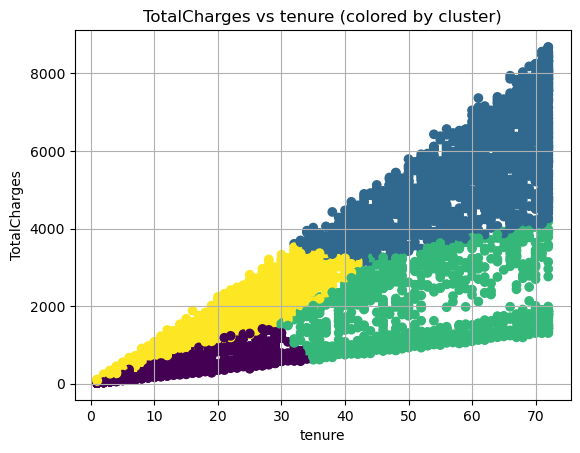

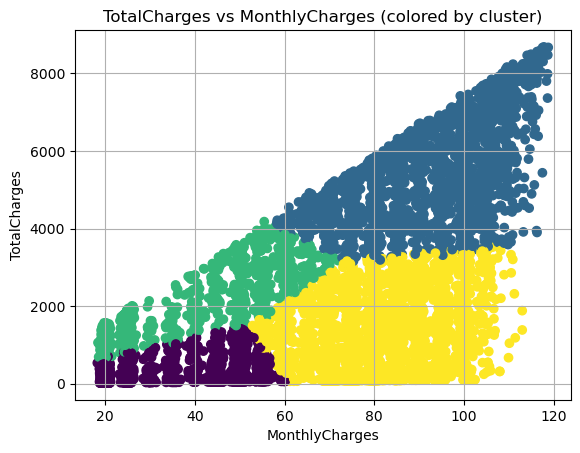


=== Contract distribution by cluster (row %) ===
Contract  Month-to-month  One year  Two year
Cluster                                     
0                  0.728     0.170     0.102
1                  0.259     0.305     0.436
2                  0.163     0.290     0.547
3                  0.861     0.118     0.021

=== InternetService distribution by cluster (row %) ===
InternetService    DSL  Fiber optic     No
Cluster                                   
0                0.483        0.000  0.517
1                0.293        0.707  0.000
2                0.444        0.001  0.555
3                0.231        0.769  0.000

=== PaymentMethod distribution by cluster (row %) ===
PaymentMethod  Bank transfer (automatic)  Credit card (automatic)  \
Cluster                                                             
0                                  0.120                    0.149   
1                                  0.322                    0.308   
2                                 

In [19]:
seg_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X = df[seg_cols].copy()

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# k means for 4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# cluster profiling
sizes = df.groupby("Cluster").size().rename("n")
churn_rate = df.groupby("Cluster")["Churn"].mean().rename("churn_rate")

means = df.groupby("Cluster")[seg_cols].mean().add_prefix("mean_")
medians = df.groupby("Cluster")[seg_cols].median().add_prefix("median_")

summary = pd.concat([sizes, churn_rate, means, medians], axis=1).sort_values("churn_rate", ascending=False)

print("\n=== Cluster Summary (sorted by churn_rate) ===")
print(summary)

print("\n=== Cluster vs Churn counts ===")
print(pd.crosstab(df["Cluster"], df["Churn"]))

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Segmentation (k=4) visualized with PCA")
plt.grid(True)
plt.show()

# non pca scattering
pairs = [
    ("tenure", "MonthlyCharges"),
    ("tenure", "TotalCharges"),
    ("MonthlyCharges", "TotalCharges")
]

for xcol, ycol in pairs:
    plt.figure()
    plt.scatter(df[xcol], df[ycol], c=df["Cluster"])
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{ycol} vs {xcol} (colored by cluster)")
    plt.grid(True)
    plt.show()

# categorical pattern discovery
cat_cols = ["Contract", "InternetService", "PaymentMethod"]
for col in cat_cols:
    if col in df.columns:
        print(f"\n=== {col} distribution by cluster (row %) ===")
        print(pd.crosstab(df["Cluster"], df[col], normalize="index").round(3))